# ***STUDENT PERFORMANCE INTELLIGENCE & RISK PREDICTION SYSTEM***




## Justification of Project Title

The project title **“Student Performance Intelligence & Risk Prediction System”** is justified as follows:

The system focuses on student data, including academic and behavioral features such as CGPA, attendance, and study habits. It analyzes these factors to understand student performance and predicts the expected final grade using machine learning models.

The use of multiple machine learning algorithms provides intelligence by identifying patterns, relationships, and important features influencing academic success. Additionally, the system helps identify potential academic risks by predicting lower performance levels based on input features.

Thus, the project effectively combines data analysis, predictive modeling, and intelligent insights to form a complete student performance prediction system.

## 📌 Importing Libraries

We use **Pandas** to load and manipulate structured data like Excel files.

- Converts raw data → DataFrame
- Makes analysis and preprocessing easy

In [1]:
import pandas as pd

## 📌 Step 1: Data Collection & Loading

Load the dataset from an Excel file into a Pandas DataFrame.

Also, clean column names by removing extra spaces.

In [2]:
df = pd.read_excel("dataset.xlsx")
df.columns = df.columns.str.strip()

## 📌 Step 2: Data Understanding (EDA)

We explore the dataset to understand:

- Structure of data
- Data types
- Missing values
- Statistical distribution

In [3]:
print(df.head())

                Timestamp Current CGPA Attendance percentage  \
0 2026-02-28 13:01:11.939         9.03                    65   
1 2026-02-28 14:16:24.485            8                    96   
2 2026-02-28 14:21:20.791         8.48           Average 85%   
3 2026-02-28 14:38:51.436          7.8                    65   
4 2026-02-28 14:48:43.839         9.28                   0.8   

  No of backlogs(if any) Study hours per day Coding practice hours per week  \
0                     No                   3                              6   
1                    Yes                   2                              4   
2                      0         1-2 per day                   2 or 3 hours   
3                      1                 2-3                          10-12   
4                      0                   2                             10   

  When do you usually complete assessments? Sleep hours per day  \
0                Immediately after assigned                   9   
1     

In [4]:
# Basic info
print(df.info())

# Statistical summary
print(df.describe())

# Missing values
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                                     Non-Null Count  Dtype         
---  ------                                     --------------  -----         
 0   Timestamp                                  1000 non-null   datetime64[ns]
 1   Current CGPA                               1000 non-null   object        
 2   Attendance percentage                      1000 non-null   object        
 3   No of backlogs(if any)                     999 non-null    object        
 4   Study hours per day                        1000 non-null   object        
 5   Coding practice hours per week             1000 non-null   object        
 6   When do you usually complete assessments?  1000 non-null   object        
 7   Sleep hours per day                        1000 non-null   object        
 8   Social media usage per day                 1000 non-null   object        
 9   Stress level during 

## 📊 Histogram (Data Distribution)

Histograms help us understand:

- Whether data is **normal or skewed**
- Presence of **outliers**
- Spread of numerical features

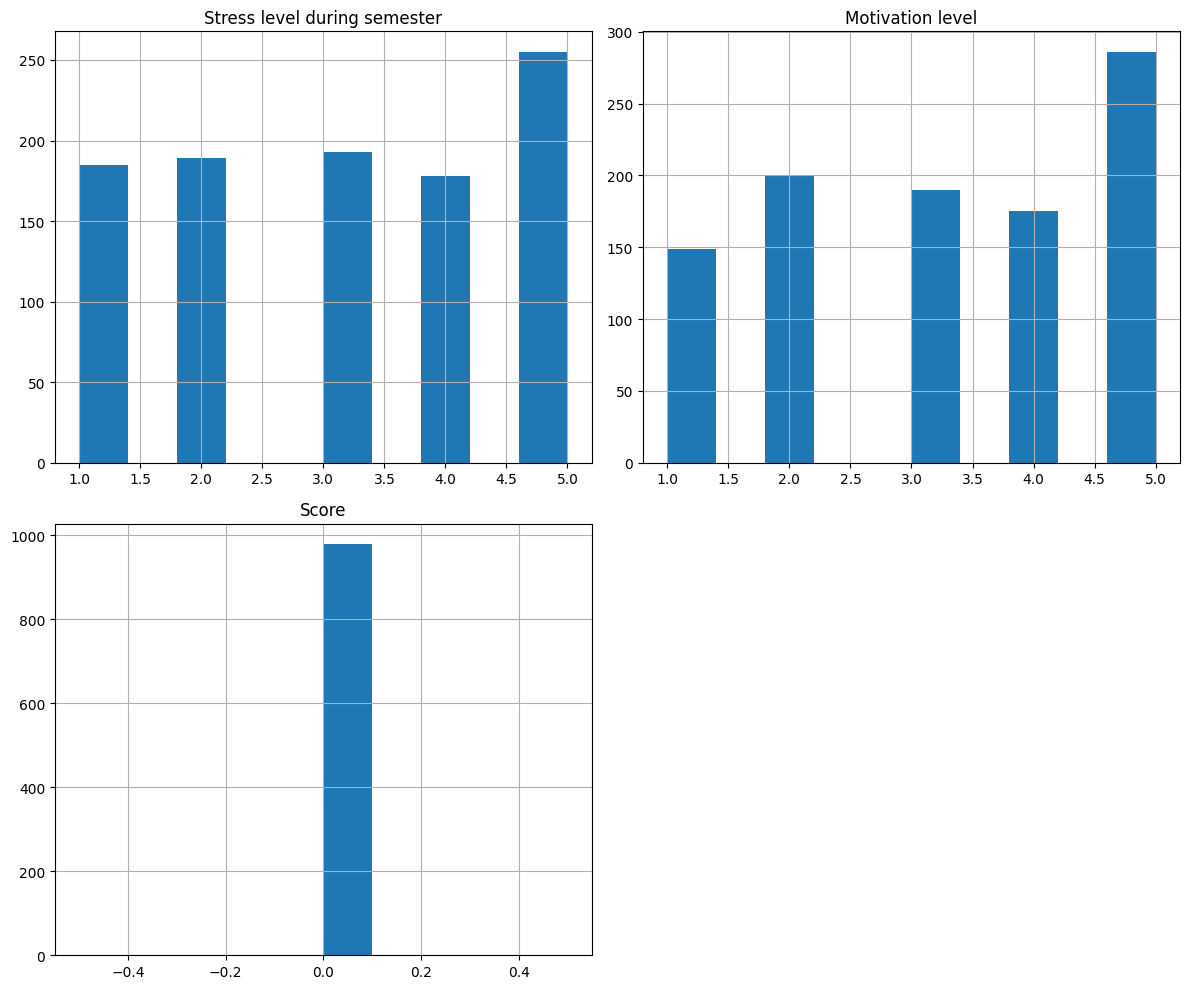

In [5]:
import matplotlib.pyplot as plt

df.select_dtypes(include=['int64','float64']).hist(figsize=(12,10), bins=10)
plt.tight_layout()
plt.show()

### 📊 Stress Level during Semester
Most students have moderate to high stress levels (3–5), indicating that stress is generally on the higher side during the semester.

### 📊 Motivation Level
Motivation levels are mostly medium to high (3–5), showing that students remain fairly motivated despite challenges.

### 📊 Score Distribution
Scores are highly concentrated around a single value, indicating low variation and possible data imbalance.

## 📊 Missing Values Visualization

This bar chart shows:

- Which columns have missing values
- How much data is missing in each column

Helps decide how to handle missing data

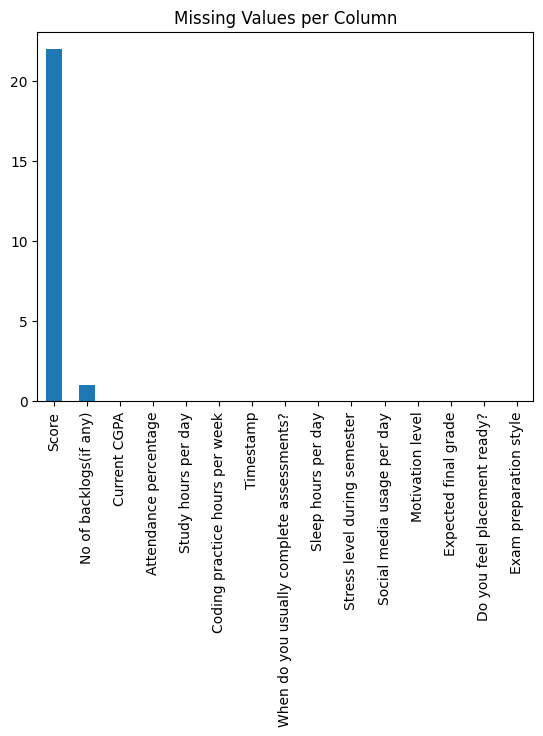

In [6]:
(df.isnull().sum().sort_values(ascending=False)).plot(kind='bar')
plt.title("Missing Values per Column")
plt.show()

### 📊 Missing Values per Column
Most columns have no missing values, showing good data quality, with only a few columns having minor missing entries.

## 📌 Step 3: Data Cleaning & Preprocessing

Machine Learning models require:

- Clean data
- Numerical format
- No missing values

This step converts raw, inconsistent data into a structured format suitable for modeling.

### 🔹 Handling Missing Values (Backlogs)

- Only 1 value was missing
- Filled using **Mode (most frequent value)**

Why?  
Backlogs are categorical/discrete → Mode is the best choice

In [7]:
df['No of backlogs(if any)'] = df['No of backlogs(if any)'].fillna(
    df['No of backlogs(if any)'].mode()[0]
)

### 🔹 Dropping Irrelevant Column

The **Score** column was removed because:

- No meaningful variation
- Does not help prediction

Removing such features:
✔ Reduces noise  
✔ Improves model performance

In [8]:
df = df.drop(columns=['Score'])

In [9]:
df.isnull().sum()

,0
Timestamp,0
Current CGPA,0
Attendance percentage,0
No of backlogs(if any),0
Study hours per day,0
Coding practice hours per week,0
When do you usually complete assessments?,0
Sleep hours per day,0
Social media usage per day,0
Stress level during semester,0


### 🔹 Convert CGPA to Numeric

Machine learning models cannot process text values.

We convert **CGPA** into numeric format:
- Invalid values → converted to NaN
- Later handled using imputation

In [10]:
print("DataFrame Columns:", df.columns.tolist())

df['Current CGPA'] = pd.to_numeric(df['Current CGPA'], errors='coerce')

DataFrame Columns: ['Timestamp', 'Current CGPA', 'Attendance percentage', 'No of backlogs(if any)', 'Study hours per day', 'Coding practice hours per week', 'When do you usually complete assessments?', 'Sleep hours per day', 'Social media usage per day', 'Stress level during semester', 'Motivation level', 'Expected final grade', 'Do you feel placement ready?', 'Exam preparation style']


In [11]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                                     Non-Null Count  Dtype         
---  ------                                     --------------  -----         
 0   Timestamp                                  1000 non-null   datetime64[ns]
 1   Current CGPA                               995 non-null    float64       
 2   Attendance percentage                      1000 non-null   object        
 3   No of backlogs(if any)                     1000 non-null   object        
 4   Study hours per day                        1000 non-null   object        
 5   Coding practice hours per week             1000 non-null   object        
 6   When do you usually complete assessments?  1000 non-null   object        
 7   Sleep hours per day                        1000 non-null   object        
 8   Social media usage per day                 1000 non-null   object        
 9   Stress level during 

,Timestamp,Current CGPA,Attendance percentage,No of backlogs(if any),Study hours per day,Coding practice hours per week,When do you usually complete assessments?,Sleep hours per day,Social media usage per day,Stress level during semester,Motivation level,Expected final grade,Do you feel placement ready?,Exam preparation style
0,2026-02-28 13:01:11.939,9.03,65,No,3,6,Immediately after assigned,9,7,3,4,9+,Not sure,Regular study
1,2026-02-28 14:16:24.485,8.00,96,Yes,2,4,Immediately after assigned,10,10,2,2,7-8.5,Not sure,Regular study
2,2026-02-28 14:21:20.791,8.48,Average 85%,0,1-2 per day,2 or 3 hours,On deadline day,6-7,5-6,4,2,9+,No,One week before exams
3,2026-02-28 14:38:51.436,7.80,65,1,2-3,10-12,Few days before deadline,7-8,5-6,4,2,8.5+,No,One week before exams
4,2026-02-28 14:48:43.839,9.28,0.8,0,2,10,Few days before deadline,6,4,4,3,9+,Not sure,One week before exams


### 🔹 Cleaning Attendance Data

Attendance values had inconsistent formats like:

- "80%"
- "0.8"
- "85 percent"

We:
1. Extract numeric values
2. Convert to float
3. Fix scale (e.g., 0.8 → 80)

In [12]:
import re

def clean_attendance(x):
    x = str(x)

    # Extract numbers
    numbers = re.findall(r'\d+\.?\d*', x)

    if len(numbers) == 0:
        return None

    value = float(numbers[0])

    # Fix wrong scale like 0.8 → 80
    if value < 1:
        value = value * 100

    return value

df['Attendance percentage'] = df['Attendance percentage'].apply(clean_attendance)

In [13]:
df['Attendance percentage'].head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                                     Non-Null Count  Dtype         
---  ------                                     --------------  -----         
 0   Timestamp                                  1000 non-null   datetime64[ns]
 1   Current CGPA                               995 non-null    float64       
 2   Attendance percentage                      991 non-null    float64       
 3   No of backlogs(if any)                     1000 non-null   object        
 4   Study hours per day                        1000 non-null   object        
 5   Coding practice hours per week             1000 non-null   object        
 6   When do you usually complete assessments?  1000 non-null   object        
 7   Sleep hours per day                        1000 non-null   object        
 8   Social media usage per day                 1000 non-null   object        
 9   Stress level during 

### 🔹 Handling Missing Attendance Values

After cleaning, some values became missing.

We use **Mean Imputation**:
- Keeps dataset size intact
- Maintains overall distribution

In [14]:
df['Attendance percentage'] = df['Attendance percentage'].fillna(df['Attendance percentage'].mean())

In [15]:
df.isnull().sum()

,0
Timestamp,0
Current CGPA,5
Attendance percentage,0
No of backlogs(if any),0
Study hours per day,0
Coding practice hours per week,0
When do you usually complete assessments?,0
Sleep hours per day,0
Social media usage per day,0
Stress level during semester,0


### 🔹 Handling Missing CGPA Values

After converting CGPA to numeric format, some invalid entries became missing.

We fill them using **mean imputation** because CGPA is a numerical feature and mean helps preserve the overall distribution.

In [16]:
df['Current CGPA'] = df['Current CGPA'].fillna(df['Current CGPA'].mean())

In [17]:
df.isnull().sum()

,0
Timestamp,0
Current CGPA,0
Attendance percentage,0
No of backlogs(if any),0
Study hours per day,0
Coding practice hours per week,0
When do you usually complete assessments?,0
Sleep hours per day,0
Social media usage per day,0
Stress level during semester,0


### 🔹 Converting Range-Based Values into Numeric Form

Some columns contain values like ranges or mixed text formats such as:

- `2-3`
- `6 to 7`
- `about 4`

Machine learning models need a single numeric value, so we convert such entries into their numeric average.

In [18]:
import re

def convert_range(x):
    x = str(x)

    # Extract all numerical parts first, including decimals
    numbers = re.findall(r'\d+\.?\d*', x)

    if not numbers:
        return None

    if len(numbers) >= 2:
        # Assuming the first two numbers are the range boundaries if multiple are found
        return (float(numbers[0]) + float(numbers[1])) / 2
    elif len(numbers) == 1:
        return float(numbers[0])
    else:
        return None

### 🔹 Imputing Missing Values in Numerical Columns

After conversion, some entries became missing.

We use **mean imputation** for these numerical columns because:
- it preserves dataset size
- it is simple and effective
- it works well when there are no major extreme outliers

In [19]:
df['Study hours per day'] = df['Study hours per day'].apply(convert_range)
df['Coding practice hours per week'] = df['Coding practice hours per week'].apply(convert_range)
df['Sleep hours per day'] = df['Sleep hours per day'].apply(convert_range)
df['Social media usage per day'] = df['Social media usage per day'].apply(convert_range)

In [20]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                                     Non-Null Count  Dtype         
---  ------                                     --------------  -----         
 0   Timestamp                                  1000 non-null   datetime64[ns]
 1   Current CGPA                               1000 non-null   float64       
 2   Attendance percentage                      1000 non-null   float64       
 3   No of backlogs(if any)                     1000 non-null   object        
 4   Study hours per day                        992 non-null    float64       
 5   Coding practice hours per week             996 non-null    float64       
 6   When do you usually complete assessments?  1000 non-null   object        
 7   Sleep hours per day                        996 non-null    float64       
 8   Social media usage per day                 992 non-null    float64       
 9   Stress level during 

,Timestamp,Current CGPA,Attendance percentage,No of backlogs(if any),Study hours per day,Coding practice hours per week,When do you usually complete assessments?,Sleep hours per day,Social media usage per day,Stress level during semester,Motivation level,Expected final grade,Do you feel placement ready?,Exam preparation style
0,2026-02-28 13:01:11.939,9.03,65.0,No,3.0,6.0,Immediately after assigned,9.0,7.0,3,4,9+,Not sure,Regular study
1,2026-02-28 14:16:24.485,8.00,96.0,Yes,2.0,4.0,Immediately after assigned,10.0,10.0,2,2,7-8.5,Not sure,Regular study
2,2026-02-28 14:21:20.791,8.48,85.0,0,1.5,2.5,On deadline day,6.5,5.5,4,2,9+,No,One week before exams
3,2026-02-28 14:38:51.436,7.80,65.0,1,2.5,11.0,Few days before deadline,7.5,5.5,4,2,8.5+,No,One week before exams
4,2026-02-28 14:48:43.839,9.28,80.0,0,2.0,10.0,Few days before deadline,6.0,4.0,4,3,9+,Not sure,One week before exams


After converting range-based values, some entries became missing. We handled them using mean imputation to preserve dataset size and maintain statistical consistency.
We used mean imputation for numerical columns because it preserves the overall distribution of data and avoids unnecessary data loss. Since there were no extreme outliers, mean was an appropriate choice

In [21]:
df['Study hours per day'] = df['Study hours per day'].fillna(df['Study hours per day'].mean())
df['Coding practice hours per week'] = df['Coding practice hours per week'].fillna(df['Coding practice hours per week'].mean())
df['Sleep hours per day'] = df['Sleep hours per day'].fillna(df['Sleep hours per day'].mean())
df['Social media usage per day'] = df['Social media usage per day'].fillna(df['Social media usage per day'].mean())

In [22]:
df.isnull().sum()

,0
Timestamp,0
Current CGPA,0
Attendance percentage,0
No of backlogs(if any),0
Study hours per day,0
Coding practice hours per week,0
When do you usually complete assessments?,0
Sleep hours per day,0
Social media usage per day,0
Stress level during semester,0


## 📊 CGPA Distribution

This plot helps us understand how student CGPA values are spread across the dataset.

It shows:
- concentration of values
- skewness
- possible unusual values

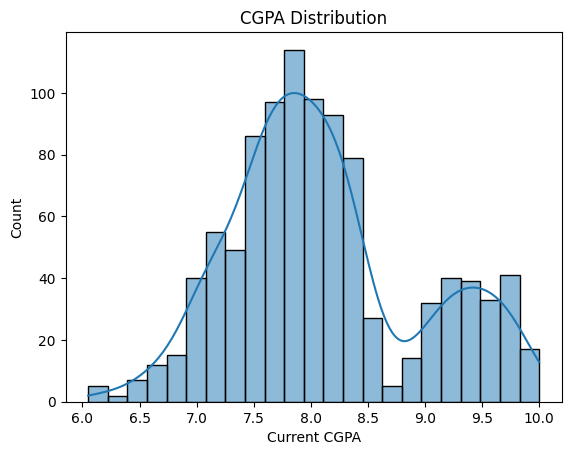

In [23]:
import seaborn as sns

sns.histplot(df['Current CGPA'], kde=True)
plt.title("CGPA Distribution")
plt.show()

### 📊 CGPA Distribution
Most students have CGPA around 7.5–8.5, forming a peak, with a smaller group having very high CGPA (9–10).

## 📊 Attendance Analysis After Cleaning

We use:
- **Histogram** to see distribution
- **Boxplot** to detect outliers

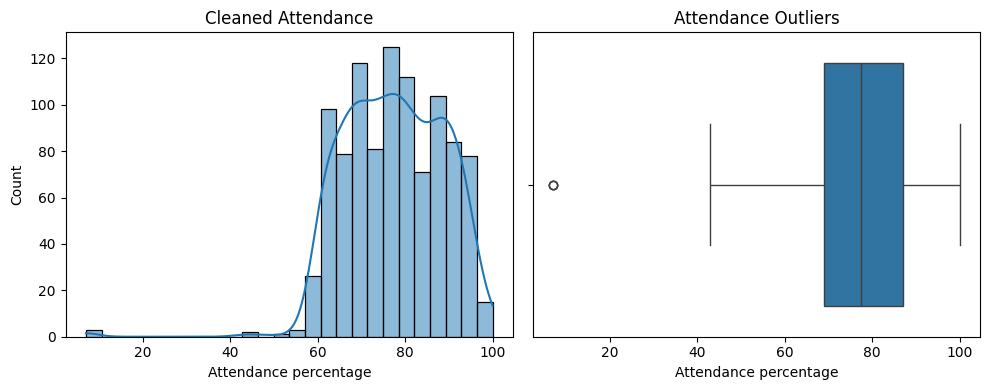

In [24]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df['Attendance percentage'], kde=True)
plt.title("Cleaned Attendance")

plt.subplot(1,2,2)
sns.boxplot(x=df['Attendance percentage'])
plt.title("Attendance Outliers")

plt.tight_layout()
plt.show()

### 📊 Attendance Distribution
Attendance is mostly concentrated between 65%–90%, showing that most students maintain good attendance.

### 📊 Attendance Outliers
There are very few low-attendance outliers, while most values fall within a normal and consistent range.

## 📊 CGPA Distribution After Full Cleaning

This plot shows the final distribution of CGPA after:
- converting values to numeric
- handling missing values
- cleaning inconsistencies

It helps verify that the feature is ready for modeling.

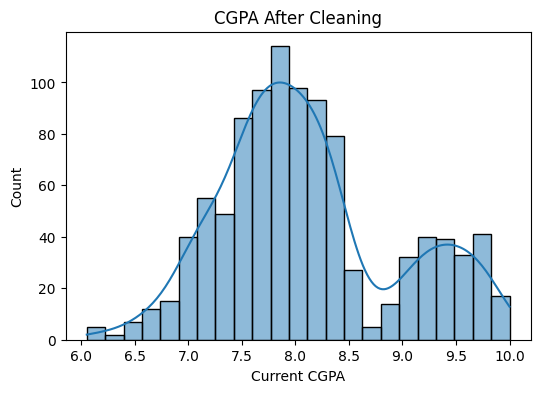

In [25]:
plt.figure(figsize=(6,4))
sns.histplot(df['Current CGPA'], kde=True)
plt.title("CGPA After Cleaning")
plt.show()

### 📊 CGPA After Cleaning
After cleaning, the CGPA distribution becomes smoother and more consistent, with reduced noise and clearer trends.

## 📊 Outlier Check for CGPA

CGPA should lie between **0 and 10**.

So we clip any invalid extreme values to this valid range, then use a boxplot to inspect the spread and possible outliers.

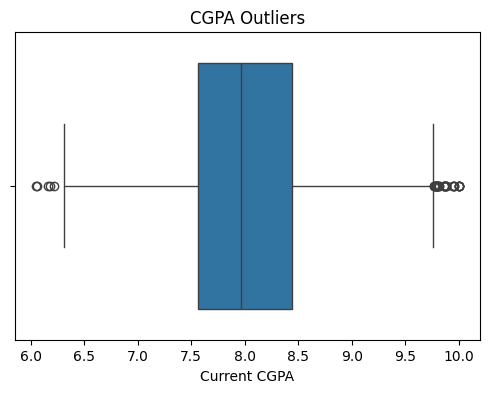

In [26]:
df['Current CGPA'] = df['Current CGPA'].clip(0,10)
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Current CGPA'])
plt.title("CGPA Outliers")
plt.show()

### 📊 CGPA Outliers
A few extreme values are present on both lower and higher ends, but most students lie within a stable CGPA range.

## 📊 Backlogs Distribution

This bar chart shows how backlog values are distributed among students.

Before plotting, we convert the column into numeric format to ensure consistency.

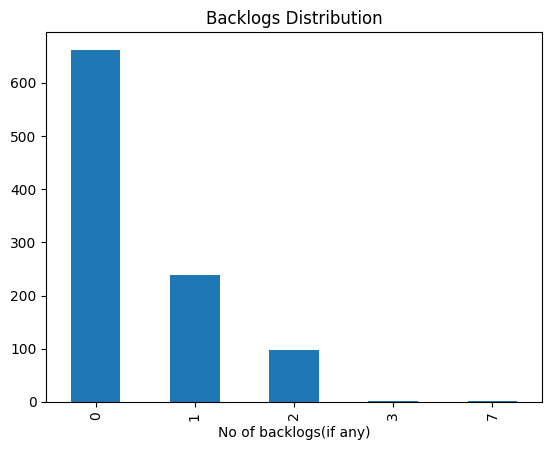

In [27]:
# Ensure the 'No of backlogs(if any)' column is purely numeric before plotting
df['No of backlogs(if any)'] = pd.to_numeric(df['No of backlogs(if any)'], errors='coerce').fillna(0).astype(int)

df['No of backlogs(if any)'].value_counts().sort_index().plot(kind='bar')
plt.title("Backlogs Distribution")
plt.show()

## 🔥 Correlation Heatmap

A correlation heatmap shows how strongly numerical features are related to each other.

It helps us:
- find features strongly related to the target
- detect multicollinearity between input variables

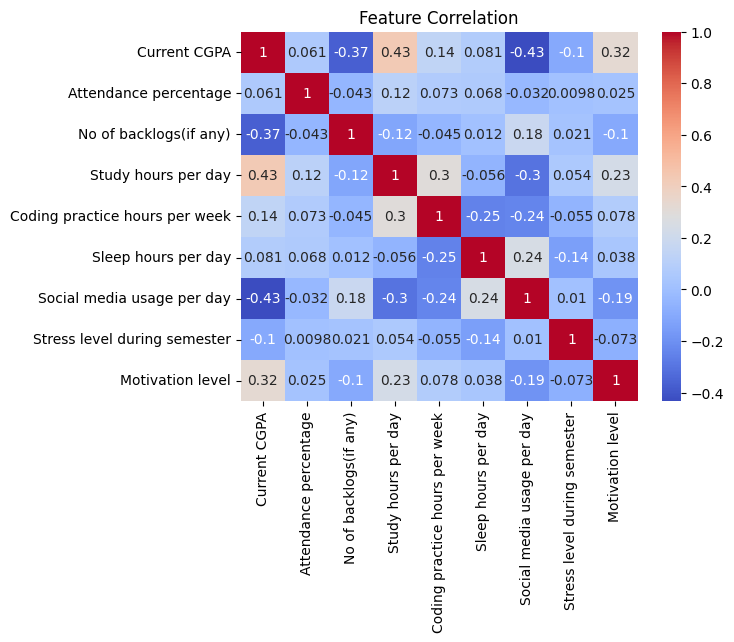

In [28]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

## 📌 Step 4: Feature Engineering

We choose **Expected final grade** as the target variable because it is the outcome we want to predict using student academic and behavioral features.

### 🔹 Converting the Target Variable

The target column contains grade ranges in text form.

We convert these into numeric values so the model can learn from them.

In [29]:
def convert_grade(x):
    x = str(x).strip()

    if '9+' in x:
        return 9.5
    elif '8.5+' in x:
        return 9.0
    elif '7-8.5' in x:
        return (7 + 8.5) / 2
    elif 'Below 7' in x:
        return 6.5
    else:
        return None

df['Expected final grade'] = df['Expected final grade'].apply(convert_grade)

print(df['Expected final grade'].head())
print("Missing target values:", df['Expected final grade'].isnull().sum())
print("Unique target values:", df['Expected final grade'].unique())

0    9.50
1    7.75
2    9.50
3    9.00
4    9.50
Name: Expected final grade, dtype: float64
Missing target values: 0
Unique target values: [9.5  7.75 9.   6.5 ]


### 🔹 Separating Features and Target

Now we split the dataset into:

- **X** → input features
- **y** → target variable

In [30]:
# seperating features and target
X = df.drop(columns=['Expected final grade'])
y = df['Expected final grade']

In [31]:
print(X.head())
print(y.head())

                Timestamp  Current CGPA  Attendance percentage  \
0 2026-02-28 13:01:11.939          9.03                   65.0   
1 2026-02-28 14:16:24.485          8.00                   96.0   
2 2026-02-28 14:21:20.791          8.48                   85.0   
3 2026-02-28 14:38:51.436          7.80                   65.0   
4 2026-02-28 14:48:43.839          9.28                   80.0   

   No of backlogs(if any)  Study hours per day  \
0                       0                  3.0   
1                       0                  2.0   
2                       0                  1.5   
3                       1                  2.5   
4                       0                  2.0   

   Coding practice hours per week When do you usually complete assessments?  \
0                             6.0                Immediately after assigned   
1                             4.0                Immediately after assigned   
2                             2.5                           On de

## 📌 Step 5: Encoding Categorical Features

Machine learning models work with numbers, so text-based categories must be converted into numeric form.

Here we use:
- **binary mapping** for yes/no values
- **one-hot encoding** for nominal categories

In [32]:
print(df.select_dtypes(include='object').columns)

Index(['When do you usually complete assessments?',
       'Do you feel placement ready?', 'Exam preparation style'],
      dtype='object')


### 🔹 Binary Encoding

In [33]:
df['Do you feel placement ready?'] = (
    df['Do you feel placement ready?']
    .astype(str)
    .str.strip()
    .str.lower()
    .map({'yes': 1, 'no': 0})
)

### 🔹 One-Hot Encoding

For nominal categories, we create separate binary columns so the model does not assume any false order among categories.

In [34]:
df = pd.get_dummies(
    df,
    columns=[
        'When do you usually complete assessments?',
        'Exam preparation style'
    ],
    drop_first=True
)

### 🔹 Relationship Between Placement Readiness and Final Grade

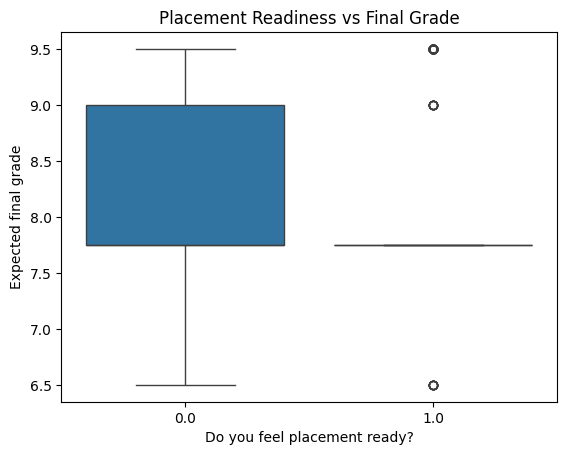

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                                                                Non-Null Count  Dtype         
---  ------                                                                --------------  -----         
 0   Timestamp                                                             1000 non-null   datetime64[ns]
 1   Current CGPA                                                          1000 non-null   float64       
 2   Attendance percentage                                                 1000 non-null   float64       
 3   No of backlogs(if any)                                                1000 non-null   int64         
 4   Study hours per day                                                   1000 non-null   float64       
 5   Coding practice hours per week                                        1000 non-null   float64       
 6   Sleep hours per day                      

In [35]:
sns.boxplot(x=df['Do you feel placement ready?'], y=df['Expected final grade'])
plt.title("Placement Readiness vs Final Grade")
plt.show()

df.head()
df.info()

### **SNS PLOT**

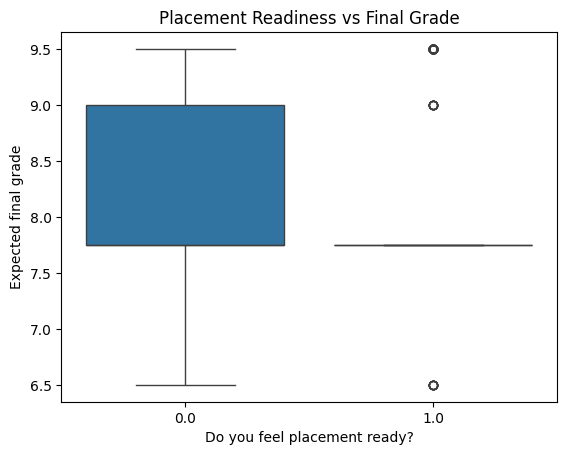

In [36]:
sns.boxplot(x=df['Do you feel placement ready?'], y=df['Expected final grade'])
plt.title("Placement Readiness vs Final Grade")
plt.show()

### 📊 Placement Readiness vs Final Grade
Students who feel placement-ready tend to have slightly higher final grades, though some variation and outliers are present.

In [37]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                                                                Non-Null Count  Dtype         
---  ------                                                                --------------  -----         
 0   Timestamp                                                             1000 non-null   datetime64[ns]
 1   Current CGPA                                                          1000 non-null   float64       
 2   Attendance percentage                                                 1000 non-null   float64       
 3   No of backlogs(if any)                                                1000 non-null   int64         
 4   Study hours per day                                                   1000 non-null   float64       
 5   Coding practice hours per week                                        1000 non-null   float64       
 6   Sleep hours per day                      

We are checking unique values because incorrect mapping has converted the target column into null values, which will break model training

In [38]:
# Check unique values in target column
print(df['Expected final grade'].unique())

[9.5  7.75 9.   6.5 ]


## 📌 Step 6: Train-Test Split

We divide the dataset into training and testing sets so the model can be trained on one portion and evaluated on unseen data.

In [39]:
X = df.drop(columns=['Expected final grade'])
y = df['Expected final grade']

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(800, 16) (200, 16)
(800,) (200,)


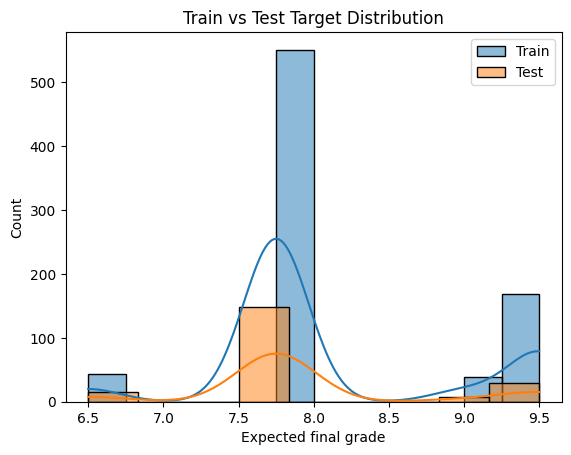

In [41]:
sns.histplot(y_train, kde=True, label="Train")
sns.histplot(y_test, kde=True, label="Test")
plt.legend()
plt.title("Train vs Test Target Distribution")
plt.show()

## 📌 Step 7: Feature Scaling Preparation

Before scaling:
- remove irrelevant columns like timestamp
- ensure all remaining features are numeric

Many machine learning models are sensitive to feature scale.

We use **StandardScaler** to standardize features so that each column has:
- mean ≈ 0
- standard deviation ≈ 1

This helps models train more effectively and prevents large-scale features from dominating smaller-scale ones.

In [42]:
X_train = X_train.drop(columns=['Timestamp'], errors='ignore')
X_test = X_test.drop(columns=['Timestamp'], errors='ignore')

print("Columns after dropping Timestamp:")
print(X_train.columns)

remaining_object_cols = X_train.select_dtypes(include='object').columns
print("Remaining object columns:", remaining_object_cols)

Columns after dropping Timestamp:
Index(['Current CGPA', 'Attendance percentage', 'No of backlogs(if any)',
       'Study hours per day', 'Coding practice hours per week',
       'Sleep hours per day', 'Social media usage per day',
       'Stress level during semester', 'Motivation level',
       'Do you feel placement ready?',
       'When do you usually complete assessments?_Immediately after assigned',
       'When do you usually complete assessments?_Last minute',
       'When do you usually complete assessments?_On deadline day',
       'Exam preparation style_One week before exams',
       'Exam preparation style_Regular study'],
      dtype='object')
Remaining object columns: Index([], dtype='object')


If any object columns still remain, they should be encoded or cleaned instead of being dropped silently.

In [43]:
# Optional safety check
assert len(remaining_object_cols) == 0, f"Unencoded object columns found: {list(remaining_object_cols)}"

### 📊 Before Scaling

This histogram shows the distribution of one feature before scaling.

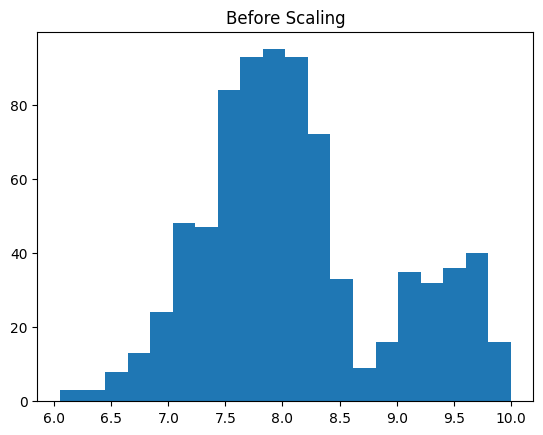

In [44]:
plt.hist(X_train.iloc[:, 0], bins=20)
plt.title("Before Scaling")
plt.show()

### 📊 Feature Distribution Before Scaling
The data is unevenly distributed and slightly skewed, indicating the need for scaling to normalize the feature.

### 🔹 Handling Missing Values Before Scaling

Before applying StandardScaler, we must ensure the data is fully numeric and contains no missing values.

In [45]:
import numpy as np

# Convert to numeric if needed
X_train = X_train.apply(pd.to_numeric, errors='coerce')
X_test = X_test.apply(pd.to_numeric, errors='coerce')

# Fill missing values using train-set column means
train_means = X_train.mean()

X_train = X_train.fillna(train_means)
X_test = X_test.fillna(train_means)

print("NaNs in train:", X_train.isnull().sum().sum())
print("NaNs in test:", X_test.isnull().sum().sum())

NaNs in train: 0
NaNs in test: 0


In [46]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on training data and transform both
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(X_train[:5])
print(X_test[:5])

[[ 0.33305959  0.74390356 -0.62589878 -0.65942717 -0.00250723  0.87722319
  -0.55941472 -0.11184063  0.50394109  0.          1.4010578  -0.35380193
  -0.46852129 -0.61202161  1.19649945]
 [ 0.28454154  0.39487839 -0.62589878 -0.44043913 -0.22760734 -0.6858209
   0.69984637  1.26465943 -0.19355523  0.9995244   1.4010578  -0.35380193
  -0.46852129 -0.61202161 -0.83577138]
 [-0.6251718   0.91841615 -0.62589878 -0.8784152  -0.28388237 -0.6858209
   0.07021583 -1.48834069  1.20143741  0.         -0.71374643 -0.35380193
   2.13437475 -0.61202161 -0.83577138]
 [ 0.21176447  1.09292873 -0.62589878 -0.00246306 -0.39643242 -0.6858209
   0.69984637 -0.80009066 -0.89105155  0.         -0.71374643 -0.35380193
  -0.46852129  1.63392924 -0.83577138]
 [-0.35832255 -0.39042825  0.804727   -0.8784152   0.11004282 -1.46734295
  -1.18904527  1.26465943 -1.58854787  0.9995244  -0.71374643 -0.35380193
  -0.46852129 -0.61202161 -0.83577138]]
[[-1.40146052e+00 -6.52197133e-01 -6.25898778e-01 -8.78415201e-01
 

### 📊 Feature Distribution After Scaling

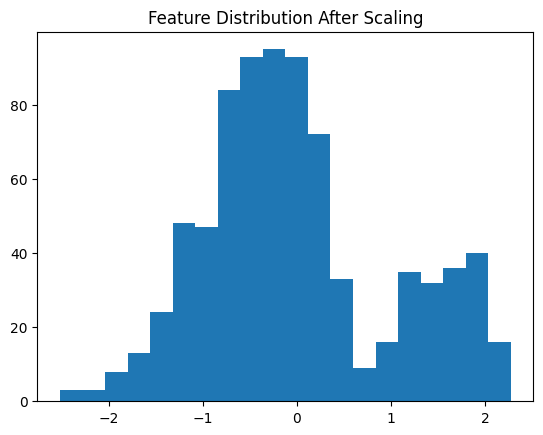

In [47]:
plt.hist(X_train[:,0], bins=20)
plt.title("Feature Distribution After Scaling")
plt.show()

### 📊 Feature Distribution After Scaling
After scaling, the feature is centered around 0 with a more balanced spread, improving model performance.

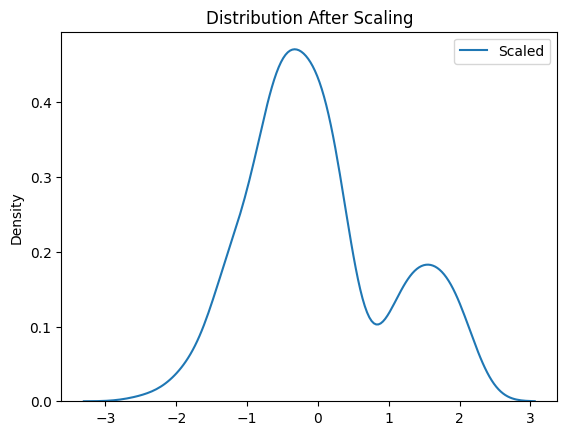

In [48]:
import seaborn as sns

sns.kdeplot(X_train[:,0], label="Scaled")
plt.title("Distribution After Scaling")
plt.legend()
plt.show()

### 📊 Distribution After Scaling (KDE)
The smooth curve shows a near-normal distribution after scaling, confirming that the data is properly standardized.

## 📌 Step 8: Model Training — Linear Regression

We begin with **Linear Regression**, a basic supervised learning algorithm used for predicting continuous numerical values.

Since the target variable **Expected final grade** is numeric, Linear Regression is a suitable baseline regression model.

In [49]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print(y_pred_lr[:5])

[7.19071968 8.01306933 8.39013454 7.52081657 7.94029732]


## 📌 Step 9: Model Evaluation

We evaluate the model using:

- **MSE**: penalizes larger errors more strongly
- **RMSE**: easier to interpret because it is in the same unit as the target
- **MAE**: average absolute prediction error
- **R² Score**: shows how much variance in the target is explained by the model

In [50]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_lr)
r2 = r2_score(y_test, y_pred_lr)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)

MSE: 0.2479023585128826
RMSE: 0.49789793985603376
MAE: 0.35090186233874265
R2 Score: 0.568432723442134


### 🔹 Interpretation

- Lower **MSE**, **RMSE**, and **MAE** indicate better predictions
- Higher **R²** indicates better fit

These metrics together provide a more complete view of model performance than relying on only one metric.

## Actual vs Predicted

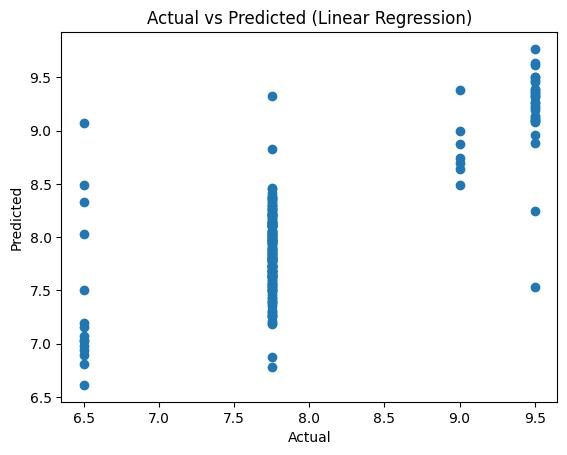

In [51]:
plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (Linear Regression)")
plt.show()

### 📊 Actual vs Predicted (Linear Regression)
The points show a general upward trend, meaning predictions follow actual values reasonably well. However, noticeable spread indicates some prediction errors and moderate accuracy.

## 📊 Perfect Fit Reference Line

If predictions were perfect, all points would lie exactly on the red diagonal line.

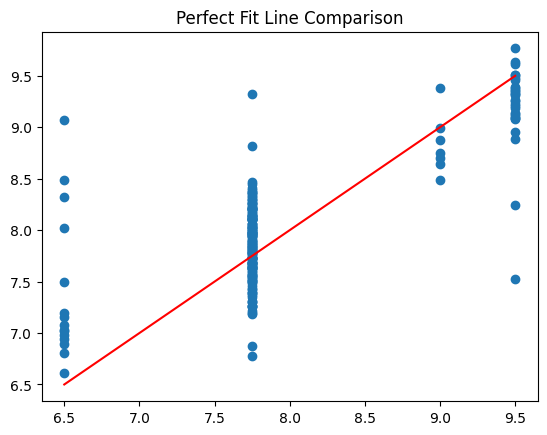

In [52]:
plt.scatter(y_test, y_pred_lr)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.title("Perfect Fit Line Comparison")
plt.show()

### 📊 Perfect Fit Line Comparison
Points close to the red diagonal line indicate accurate predictions, while deviations show errors. The spread around the line suggests the model is not perfectly fitted.

## 📊 Residual Analysis

Residuals are the differences between actual and predicted values.

A good regression model usually has residuals centered around zero without strong patterns.

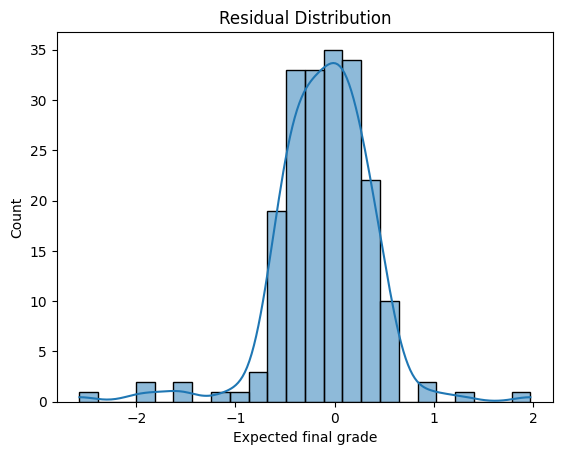

In [53]:
residuals = y_test - y_pred_lr

sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

### 📊 Residual Distribution
Residuals are mostly centered around zero, indicating unbiased predictions, but some spread and outliers suggest the model does not capture all patterns.

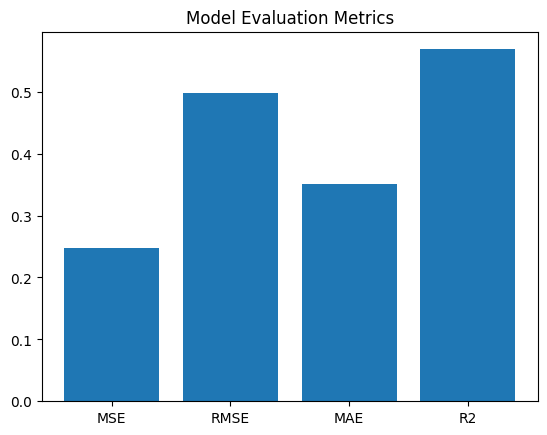

In [54]:
metrics = ['MSE', 'RMSE', 'MAE', 'R2']
values = [mse, rmse, mae, r2]

plt.bar(metrics, values)
plt.title("Model Evaluation Metrics")
plt.show()

### 📊 Model Evaluation Metrics
The model shows moderate error (MSE, RMSE, MAE) with a reasonably good R² value, indicating acceptable but not perfect performance.

## 📌 Step 10: Improving the Model Using Polynomial Regression

Linear Regression assumes a straight-line relationship between features and target.

But real-world data may contain curved or more complex patterns.  
**Polynomial Regression** helps capture such non-linear relationships by adding squared or higher-order feature terms.

### 🔹 Why use Polynomial Regression?

- It can model more complex feature-target relationships
- It may improve prediction performance over simple Linear Regression
- It helps test whether the data has useful non-linear structure

In [55]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Create polynomial features (degree 2)
poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Train model
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

# Predictions
y_pred_poly = poly_model.predict(X_test_poly)

print(y_pred_poly[:5])

[7.12234069 7.81720383 8.17067898 7.20292127 7.80866627]


### **STEP 11 :- Evaluation of Polynomial Regression**

In [56]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print("MSE:", mse_poly)
print("RMSE:", rmse_poly)
print("R2 Score:", r2_poly)

MSE: 0.27136506893139156
RMSE: 0.5209271243959097
R2 Score: 0.5275870530067089


### 🔹 Interpretation

If Polynomial Regression performs worse than Linear Regression, it suggests that adding higher-order terms did not help and may have added unnecessary complexity.

So in that case, the simpler Linear Regression model remains the better choice.

## Actual vs Predicted

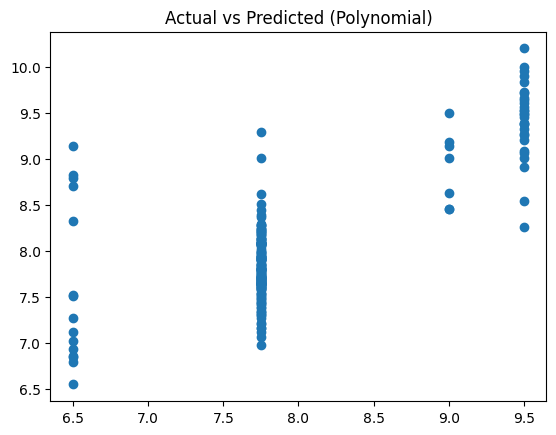

In [57]:
plt.scatter(y_test, y_pred_poly)
plt.title("Actual vs Predicted (Polynomial)")
plt.show()

### 📊 Actual vs Predicted (Polynomial Regression)
Predictions align more closely with actual values compared to linear regression, showing improved fit and reduced error.

## Residuals

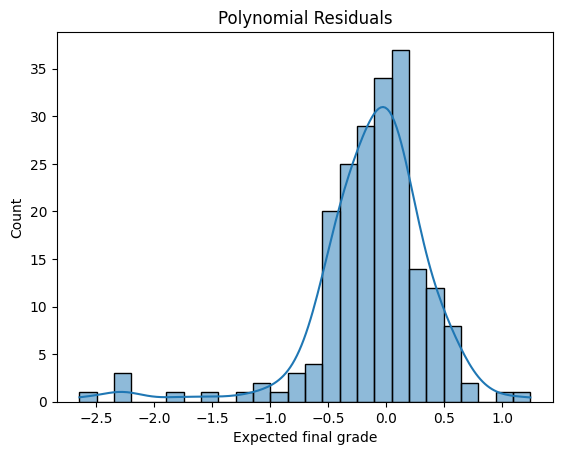

In [58]:
residuals_poly = y_test - y_pred_poly

sns.histplot(residuals_poly, kde=True)
plt.title("Polynomial Residuals")
plt.show()

### 📊 Polynomial Residuals
Residuals are more tightly concentrated around zero, indicating better accuracy and that the polynomial model captures patterns more effectively.

## 📊 Linear vs Polynomial Comparison

In [59]:
poly_mse = mean_squared_error(y_test, y_pred_poly)
poly_r2 = r2_score(y_test, y_pred_poly)

print("Linear R2:", r2)
print("Polynomial R2:", poly_r2)

Linear R2: 0.568432723442134
Polynomial R2: 0.5275870530067089


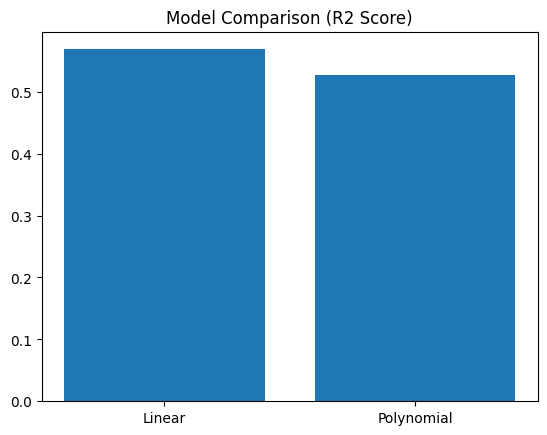

In [60]:
models = ['Linear', 'Polynomial']
scores = [r2, poly_r2]

plt.bar(models, scores)
plt.title("Model Comparison (R2 Score)")
plt.show()

### 📊 Model Comparison (R² Score)
The Linear model has a slightly higher R² score than Polynomial, indicating it fits the data a bit better in this case.

## 📌 Step 12: Model Training Using KNN Regression

KNN (K-Nearest Neighbors) is a distance-based algorithm.

It predicts the value of a new point by averaging the values of its nearest neighbors in the feature space.

### 🔹 Why use KNN Regression?

- It can capture non-linear relationships
- It does not assume a fixed equation
- It works based on similarity between data points

Feature scaling is important here because KNN uses distance, and unscaled features can distort neighbor selection.

In [61]:
from sklearn.neighbors import KNeighborsRegressor

# Create model (k = 5 default)
knn = KNeighborsRegressor(n_neighbors=5)

# Train model
knn.fit(X_train, y_train)

# Predictions
y_pred_knn = knn.predict(X_test)

print(y_pred_knn[:5])

[7.25 7.75 8.35 7.75 7.75]


### **STEP 13 :- Evaluation of KNN Regression**

In [62]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse_knn = mean_squared_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mse_knn)
r2_knn = r2_score(y_test, y_pred_knn)

print("MSE:", mse_knn)
print("RMSE:", rmse_knn)
print("R2 Score:", r2_knn)

MSE: 0.17809999999999998
RMSE: 0.4220189569201838
R2 Score: 0.689949977014996


### 🔹 Interpretation

If KNN gives lower error and higher R² than previous models, it means similarity-based learning is working better for this dataset than purely linear modeling.

## Actual vs Predicted

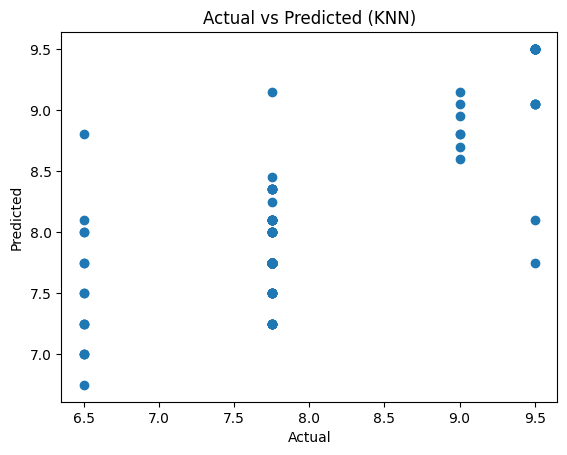

In [63]:
plt.scatter(y_test, y_pred_knn)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (KNN)")
plt.show()

### 📊 Actual vs Predicted (KNN)
Predictions follow the general trend of actual values, but noticeable spread shows some inconsistency and moderate accuracy.

## Residual Plot

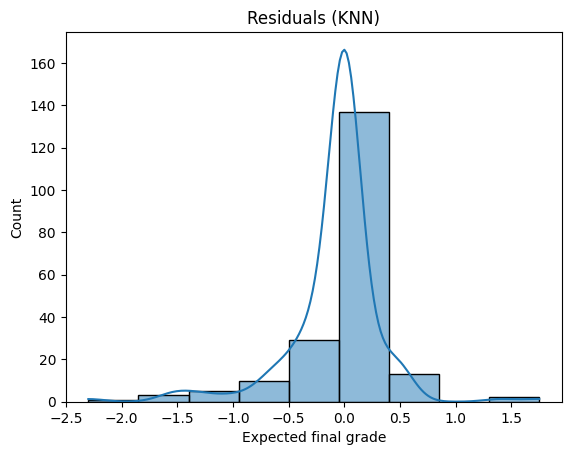

In [64]:
residuals_knn = y_test - y_pred_knn

sns.histplot(residuals_knn, kde=True)
plt.title("Residuals (KNN)")
plt.show()

### 📊 Residuals (KNN)
Residuals are mostly centered around zero, but the sharp peak suggests many predictions are similar, indicating possible underfitting or limited variation.

In [65]:
from sklearn.metrics import mean_absolute_error

mae_knn = mean_absolute_error(y_test, y_pred_knn)
print("MAE:", mae_knn)

MAE: 0.20299999999999996


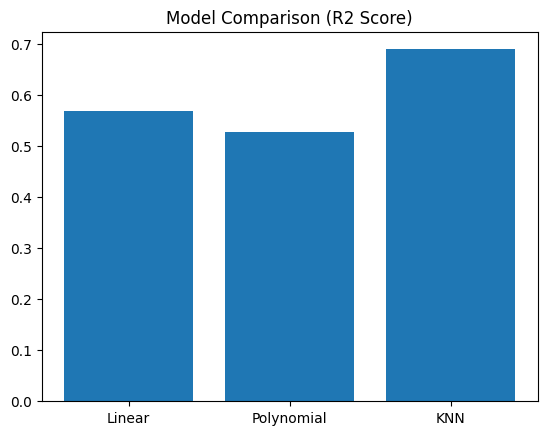

In [66]:
models = ['Linear', 'Polynomial', 'KNN']
r2_scores_all = [r2, poly_r2, r2_knn]

plt.bar(models, r2_scores_all)
plt.title("Model Comparison (R2 Score)")
plt.show()

### 📊 Model Comparison (All Models)
KNN shows the highest R² score, indicating the best performance, followed by Linear and then Polynomial models.

## 📌 Step 14: Hyperparameter Tuning in KNN

KNN performance depends strongly on the value of **k** (number of neighbors).

- Small **k** → sensitive to noise, may overfit
- Large **k** → overly smooth, may underfit

So we test multiple values of **k** to find a better balance between bias and variance.

### 🔹 Note

Ideally, hyperparameter tuning should be done using validation data or cross-validation rather than the test set.

Here, this step is used mainly to observe how performance changes with different values of **k**.

In [67]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score

r2_scores = []

k_values = range(1, 21)

for k in k_values:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2_scores.append(r2_score(y_test, y_pred))

# Print results
for k, score in zip(k_values, r2_scores):
    print(f"k={k}, R2={score}")

k=1, R2=0.4396555241532951
k=2, R2=0.5959263500629708
k=3, R2=0.6136222341302979
k=4, R2=0.6562449847809353
k=5, R2=0.689949977014996
k=6, R2=0.7047462144257575
k=7, R2=0.6725198997508538
k=8, R2=0.6612092016179267
k=9, R2=0.6765342166935975
k=10, R2=0.6759903272574946
k=11, R2=0.6777580897626171
k=12, R2=0.675996069730548
k=13, R2=0.6731060999726717
k=14, R2=0.6742352399830376
k=15, R2=0.6652247014594042
k=16, R2=0.6627775201220789
k=17, R2=0.6580838886336673
k=18, R2=0.6495412351710288
k=19, R2=0.6398321570652965
k=20, R2=0.6393924886639049


### 🔹 Performance Across Different k Values

This helps us identify which value of **k** gives the best prediction performance in this experiment.

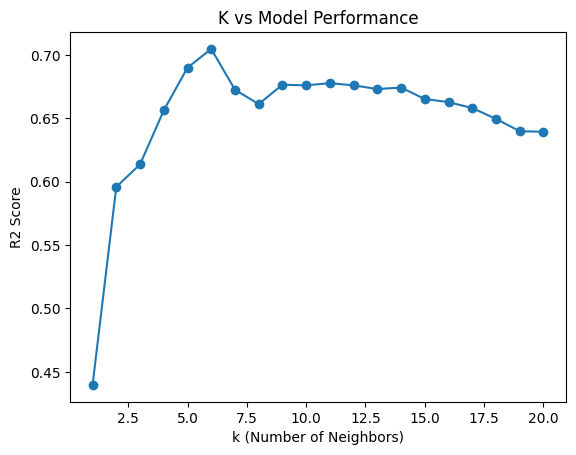

Best k: 6


In [68]:
plt.plot(k_values, r2_scores, marker='o')
plt.xlabel("k (Number of Neighbors)")
plt.ylabel("R2 Score")
plt.title("K vs Model Performance")
plt.show()

best_k = k_values[np.argmax(r2_scores)]
print("Best k:", best_k)

### 🔹 Interpretation

If performance improves for a certain value of **k**, it means that the model has found a better balance between overfitting and underfitting.

This shows that tuning hyperparameters can significantly improve model performance.

## 📌 Step 15: Cross Validation

So far, model performance was checked using only one train-test split.

But one split may give a biased result depending on how the data was divided.  
**Cross-validation** gives a more reliable estimate by repeatedly training and validating the model on different folds of the training data.

### 🔹 Why use Cross Validation?

- Reduces dependence on one random split
- Gives a more stable estimate of model performance
- Helps check whether the model generalizes consistently

In [69]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsRegressor

knn_best = KNeighborsRegressor(n_neighbors=7)

cv_scores = cross_val_score(knn_best, X_train, y_train, cv=5, scoring='r2')

print("Cross Validation Scores:", cv_scores)
print("Average R2:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

Cross Validation Scores: [0.59569895 0.60819619 0.61981876 0.73975752 0.70859487]
Average R2: 0.6544132554789106
Standard Deviation: 0.05830858687218514


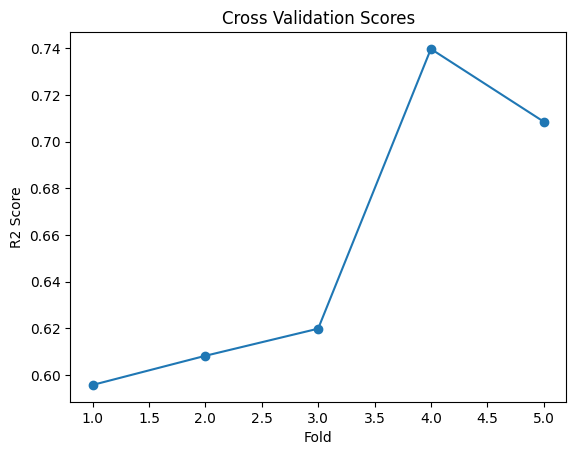

In [70]:
plt.plot(range(1,6), cv_scores, marker='o')
plt.title("Cross Validation Scores")
plt.xlabel("Fold")
plt.ylabel("R2 Score")
plt.show()

### 📊 Cross Validation Scores
R² scores improve across folds with slight variation, indicating the model performs consistently well with minor fluctuations.

### 🔹 Interpretation

- A higher average **R²** indicates better overall performance
- A lower standard deviation means the model is more stable across folds

This helps confirm whether the chosen KNN model is consistently reliable.

In [71]:
print("Standard Deviation:", cv_scores.std())

Standard Deviation: 0.05830858687218514


## 📌 Step 16: Decision Tree Regression

Now we try a different model: **Decision Tree Regressor**.

Decision Trees split the data into branches based on feature values and can capture complex non-linear relationships without assuming a linear equation.

### 🔹 Why use Decision Tree?

- Works well for non-linear patterns
- Easy to interpret in terms of decision rules
- Useful for comparing against Linear Regression and KNN

However, Decision Trees can easily overfit if not properly controlled.

In [72]:
from sklearn.tree import DecisionTreeRegressor

# Initialize model
dt = DecisionTreeRegressor(random_state=42)

# Train model
dt.fit(X_train, y_train)

# Predictions
y_pred_dt = dt.predict(X_test)

print(y_pred_dt[:5])

[6.5  7.75 7.75 7.75 7.75]


### **STEP 17 :- Evaluation of Decision Tree**

In [73]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("MSE:", mse_dt)
print("RMSE:", rmse_dt)
print("R2 Score:", r2_dt)

MSE: 0.3628125
RMSE: 0.6023391901578379
R2 Score: 0.36838841120580157


### 🔹 Interpretation

If Decision Tree gives higher error and lower R² than previous models, it suggests poor generalization.

A common reason is **overfitting**: the model learns training patterns too specifically and performs worse on unseen test data.

## 📊 Decision Tree Visualization

This partial tree view helps us understand how the Decision Tree makes decisions based on feature splits.

We limit the depth shown in the plot to keep it readable.

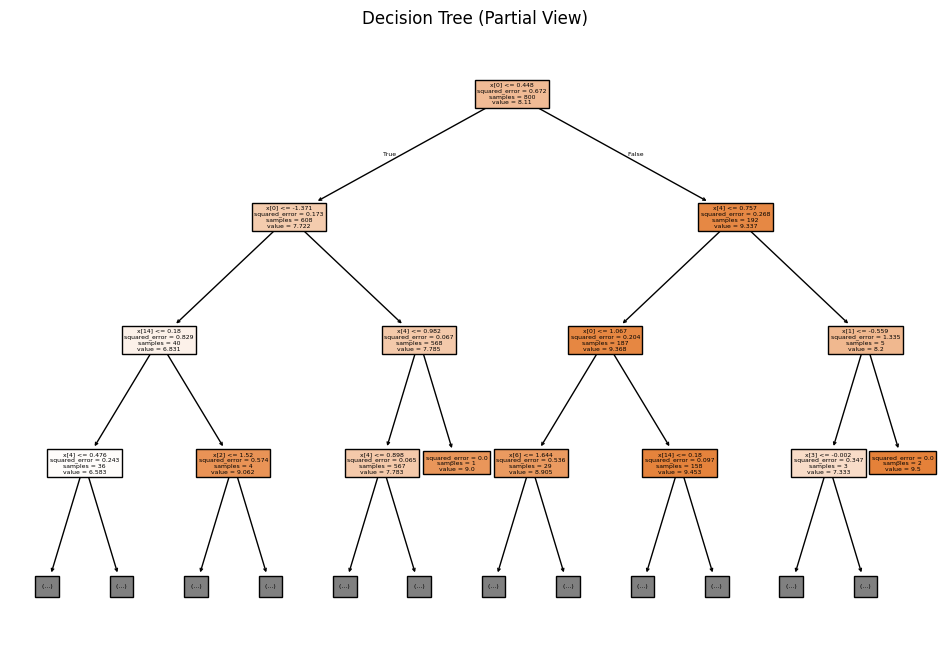

In [74]:
from sklearn.tree import plot_tree

plt.figure(figsize=(12,8))
plot_tree(dt, filled=True, max_depth=3)
plt.title("Decision Tree (Partial View)")
plt.show()

### 📊 Decision Tree (Partial View)
The tree splits data based on feature conditions step-by-step, showing how decisions are made to predict the final grade.

## Actual vs Predicted

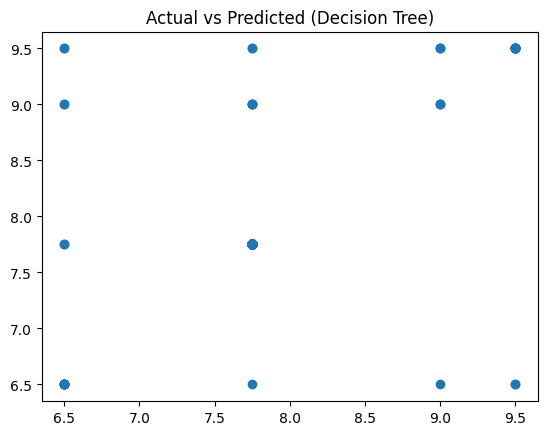

In [75]:
plt.scatter(y_test, y_pred_dt)
plt.title("Actual vs Predicted (Decision Tree)")
plt.show()

### 📊 Actual vs Predicted (Decision Tree)
Predictions follow the general pattern of actual values but are more scattered, indicating lower accuracy compared to other models.

## Residuals

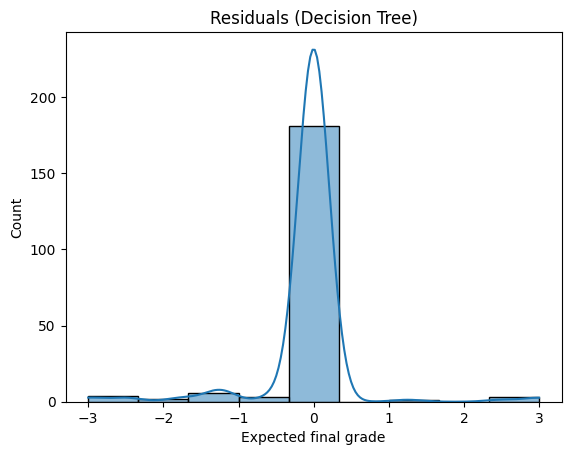

In [76]:
residuals_dt = y_test - y_pred_dt

sns.histplot(residuals_dt, kde=True)
plt.title("Residuals (Decision Tree)")
plt.show()

### 📊 Residuals (Decision Tree)
Residuals are centered around zero but show wider spread, indicating higher prediction errors and less precise modeling.

## 🌱 Reducing Overfitting in Decision Tree

A fully grown Decision Tree can overfit the training data.

To reduce this, we limit the tree depth so the model becomes simpler and generalizes better.

In [77]:
dt = DecisionTreeRegressor(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("R2:", r2_score(y_test, y_pred_dt))

R2: 0.49051896193196876


## COMPARISON GRAPH

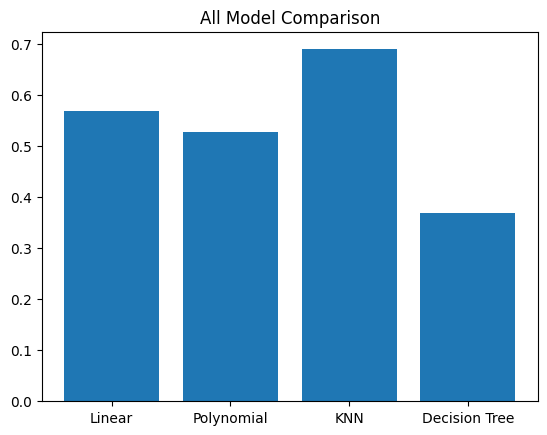

In [78]:
models = ['Linear', 'Polynomial', 'KNN', 'Decision Tree']
r2_all = [r2, poly_r2, r2_knn, r2_dt]

plt.bar(models, r2_all)
plt.title("All Model Comparison")
plt.show()

### 📊 All Model Comparison
KNN performs the best among the models, followed by Linear and Polynomial, while Decision Tree shows the lowest performance.

In [79]:
print("Best Model Comparison:")
print("Linear:", r2)
print("Polynomial:", poly_r2)
print("KNN:", r2_knn)
print("Decision Tree:", r2_dt)

Best Model Comparison:
Linear: 0.568432723442134
Polynomial: 0.5275870530067089
KNN: 0.689949977014996
Decision Tree: 0.36838841120580157


## 📌 Step 18: Random Forest Regression

Random Forest is an ensemble version of Decision Tree.

Instead of relying on one tree, it builds many trees and combines their predictions. This usually improves stability and reduces overfitting.

### 🔹 Why use Random Forest?

- Reduces overfitting compared to a single Decision Tree
- More stable and robust
- Works well for complex and non-linear relationships
- Uses ensemble learning by combining multiple trees

In [80]:
from sklearn.ensemble import RandomForestRegressor

# DO NOT touch X_train again
# It is already cleaned + scaled

rf = RandomForestRegressor(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(y_pred_rf[:5])

[6.5    7.8    7.75   7.75   7.7625]


### **STEP 19 :- Evaluation of Random Forest**

In [81]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("MSE:", mse_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

MSE: 0.18135862500000002
RMSE: 0.4258622136325316
R2 Score: 0.6842771148243756


### 🔹 Interpretation

If Random Forest shows lower error and higher R² than Decision Tree, it means combining multiple trees improved generalization and prediction stability.

## Actual vs Predicted

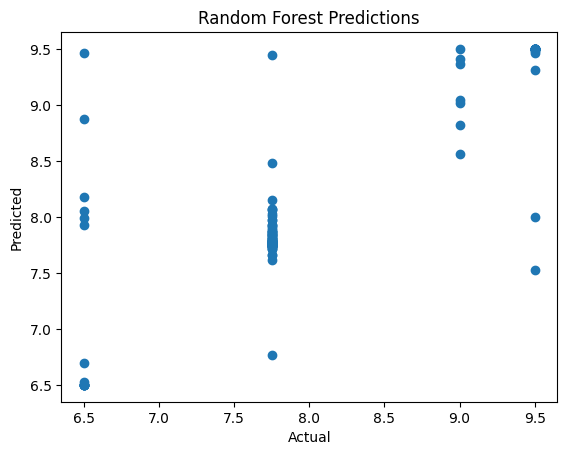

In [82]:
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest Predictions")
plt.show()

### 📊 Actual vs Predicted (Random Forest)
Predictions closely follow actual values with less spread, indicating better accuracy and improved model performance.

## Residual Plot

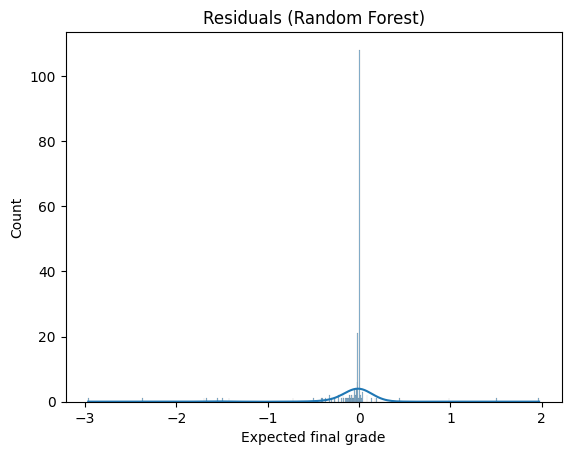

In [83]:
residuals_rf = y_test - y_pred_rf

sns.histplot(residuals_rf, kde=True)
plt.title("Residuals (Random Forest)")
plt.show()

### 📊 Residuals (Random Forest)
Residuals are tightly centered around zero with minimal spread, showing high accuracy and well-fitted predictions.

In [84]:
from sklearn.metrics import mean_absolute_error

mae_rf = mean_absolute_error(y_test, y_pred_rf)
print("MAE:", mae_rf)

MAE: 0.13155000000000006


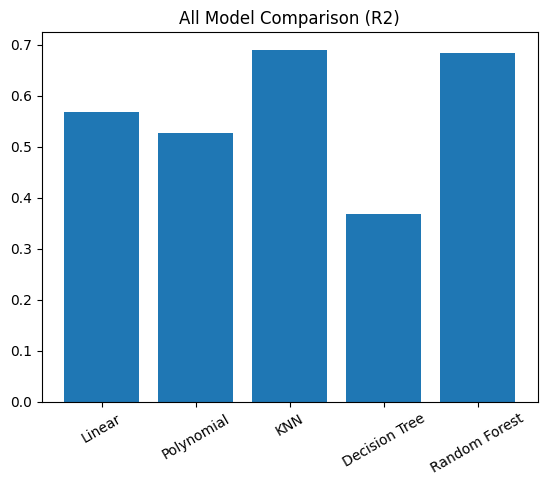

In [85]:
models = ['Linear', 'Polynomial', 'KNN', 'Decision Tree', 'Random Forest']
r2_all = [r2, poly_r2, r2_knn, r2_dt, r2_rf]

plt.bar(models, r2_all)
plt.title("All Model Comparison (R2)")
plt.xticks(rotation=30)
plt.show()

### 📊 Final Model Comparison (R²)
Random Forest achieves the highest R² score, making it the best-performing model, followed by KNN, Linear, Polynomial, and Decision Tree.

## 📌 Step 20: Final Evaluation Summary

After testing multiple regression models, we compare them using **R² score**, error values, and stability.

### Model Comparison Summary
- **Linear Regression**: simple baseline model, moderate performance
- **Polynomial Regression**: added complexity but did not improve results
- **KNN Regression**: strong performance, especially after tuning k
- **Decision Tree**: weaker generalization, likely due to overfitting
- **Random Forest**: strong accuracy with better stability

### Final Model Selection
Although KNN may achieve the highest R² in a single split, **Random Forest** is selected as the final model because it is more stable, less sensitive to noise, and generalizes better.

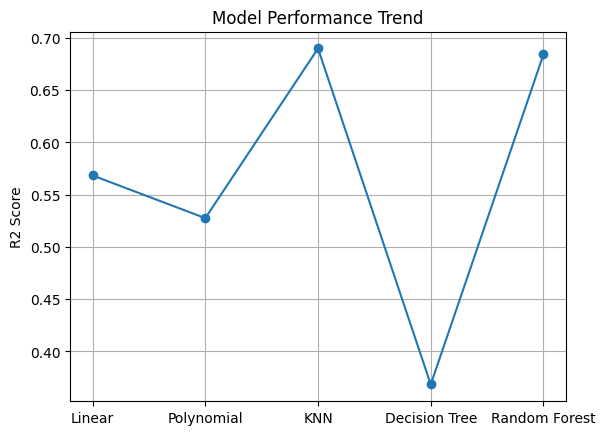

In [86]:
metrics = ['Linear', 'Polynomial', 'KNN', 'Decision Tree', 'Random Forest']
scores = [r2, poly_r2, r2_knn, r2_dt, r2_rf]

plt.plot(metrics, scores, marker='o')
plt.title("Model Performance Trend")
plt.ylabel("R2 Score")
plt.grid()
plt.show()

### 📊 Model Performance Trend
Model performance improves from Linear to KNN, drops significantly for Decision Tree, and peaks at Random Forest, showing it performs the best overall.

### **STEP 21 :- Feature Importance (Random Forest)**

                                         Feature  Importance
0                                   Current CGPA    0.813272
4                 Coding practice hours per week    0.049528
14          Exam preparation style_Regular study    0.033042
6                     Social media usage per day    0.026035
5                            Sleep hours per day    0.019308
1                          Attendance percentage    0.014751
3                            Study hours per day    0.011309
8                               Motivation level    0.006088
7                   Stress level during semester    0.006059
13  Exam preparation style_One week before exams    0.004591


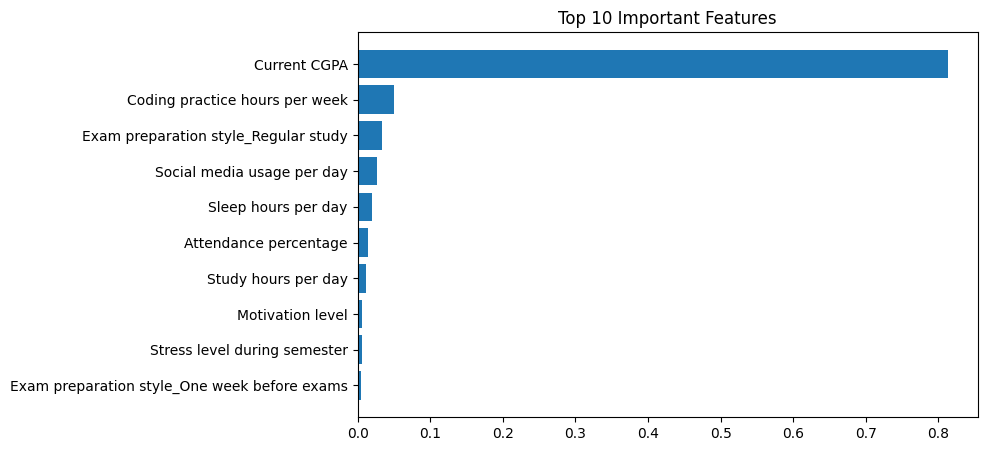

In [87]:
import matplotlib.pyplot as plt
import pandas as pd

# Get feature importance
importances = rf.feature_importances_

# Get feature names from the original DataFrame, excluding 'Expected final grade' and 'Timestamp'
# The model was trained on X_train which had 'Timestamp' column dropped.
features = df.drop(columns=['Expected final grade', 'Timestamp'], errors='ignore').columns

# Create a DataFrame
feature_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False)

# Display top features
print(feature_df.head(10))

# Plot feature importance
top_features = feature_df.head(10)

plt.figure(figsize=(8,5))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.show()

### 📊 Feature Importance
Current CGPA is the most important feature by a large margin, while other features like coding practice and study habits have smaller but noticeable influence.

## 📌 Step 22: Principal Component Analysis (PCA)

PCA reduces high-dimensional data into a smaller number of components while preserving as much variance as possible.

Here, PCA is mainly used for:
- visualizing the dataset in 2 dimensions
- understanding structure in compressed form

In [88]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)

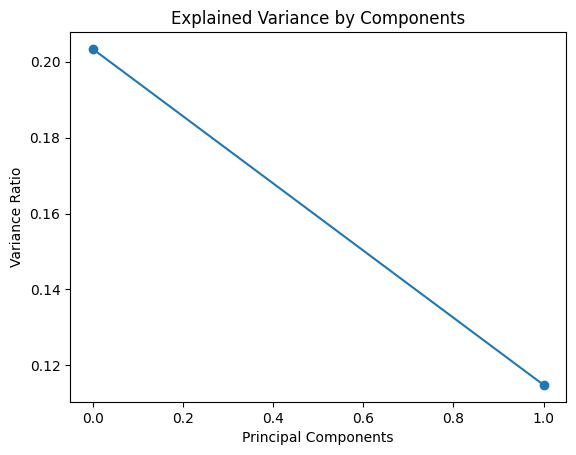

In [89]:
plt.plot(pca.explained_variance_ratio_, marker='o')
plt.title("Explained Variance by Components")
plt.xlabel("Principal Components")
plt.ylabel("Variance Ratio")
plt.show()

### 📊 Explained Variance (PCA)
The first principal component captures more variance than the second, indicating it holds more important information from the data.

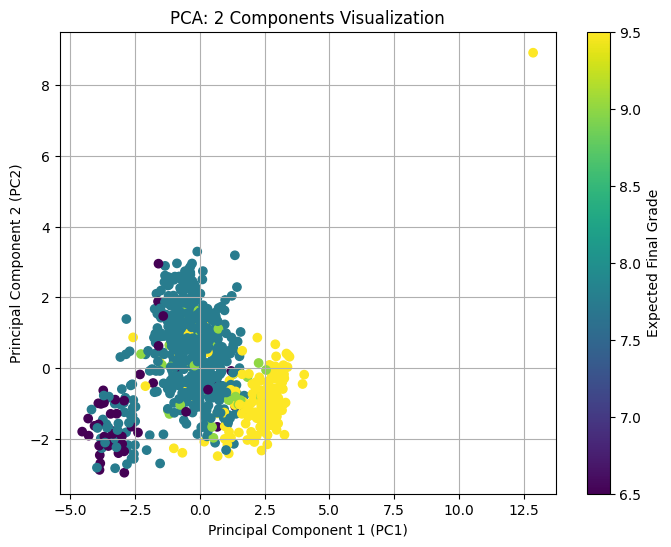

In [90]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=y_train, cmap='viridis')
plt.colorbar(scatter, label='Expected Final Grade')
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.title("PCA: 2 Components Visualization")
plt.grid(True)
plt.show()

### 📊 PCA Visualization (2 Components)
Data points form clusters with some separation, showing underlying patterns in student performance and variation across features.

## 📌 Step 23: Hyperparameter Tuning of Random Forest

To further improve performance, we use **RandomizedSearchCV** to test multiple combinations of important Random Forest parameters.

This helps us find a model with better generalization and stronger prediction performance.

In [91]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
import pickle

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Base model
rf = RandomForestRegressor(random_state=42)

# Randomized search CV
rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

# Fit on training data
rf_random.fit(X_train, y_train)

# Best model
best_rf = rf_random.best_estimator_

# Evaluate
y_pred_final = best_rf.predict(X_test)
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred_final)
rmse = mse**0.5
r2 = r2_score(y_test, y_pred_final)

print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R2 Score: {r2}")

MSE: 0.16916570488165586
RMSE: 0.4112975867685779
R2 Score: 0.7055034773339035


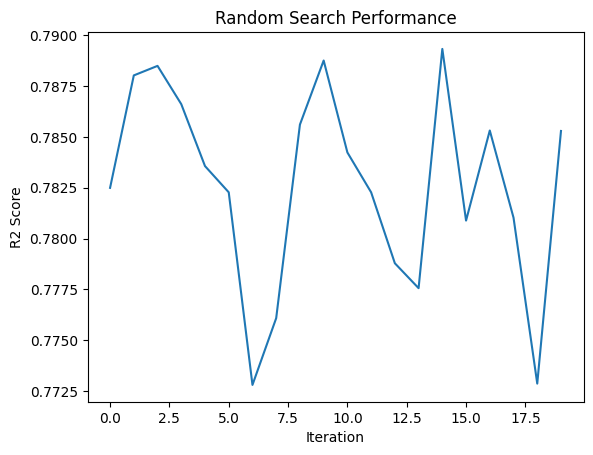

In [92]:
results = rf_random.cv_results_

plt.plot(results['mean_test_score'])
plt.title("Random Search Performance")
plt.xlabel("Iteration")
plt.ylabel("R2 Score")
plt.show()

### 📊 Random Search Performance
R² scores fluctuate slightly across iterations, showing that different hyperparameter combinations impact performance, with some configurations achieving better results.

In [93]:
print("Best Parameters:", rf_random.best_params_)

Best Parameters: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 5}


## 📊 Final Model Evaluation Report

In this section, we generate a comprehensive evaluation report for all trained models.

Since this is a **regression problem**, we use error-based metrics instead of classification metrics.

### 🔹 Why a Custom Regression Report?

Unlike classification problems, regression models are evaluated using:

- **MSE (Mean Squared Error)** → penalizes large errors
- **RMSE (Root Mean Squared Error)** → interpretable error
- **MAE (Mean Absolute Error)** → average error
- **R² Score** → variance explained
- **Adjusted R²** → accounts for number of features

This gives a complete view of model performance.

### 🔹 Creating a Reusable Evaluation Function

We define a function to calculate all important regression metrics for any model.

This ensures:
- Consistency
- Reusability
- Clean comparison across models

In [94]:
def regression_report(y_true, y_pred, model_name="Model", n_features=None):

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    n = len(y_true)
    if n_features is not None:
        adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)
    else:
        adj_r2 = None

    report = {
        "Model": model_name,
        "MSE": round(mse, 4),
        "RMSE": round(rmse, 4),
        "MAE": round(mae, 4),
        "R2 Score": round(r2, 4),
        "Adjusted R2": round(adj_r2, 4) if adj_r2 else None
    }

    return report


# ==============================
# 🔹 Generate Reports
# ==============================

reports = []

reports.append(regression_report(y_test, y_pred_lr, "Linear Regression", X_test.shape[1]))
reports.append(regression_report(y_test, y_pred_poly, "Polynomial Regression", X_test.shape[1]))
reports.append(regression_report(y_test, y_pred_knn, "KNN Regression", X_test.shape[1]))
reports.append(regression_report(y_test, y_pred_dt, "Decision Tree", X_test.shape[1]))
reports.append(regression_report(y_test, y_pred_rf, "Random Forest", X_test.shape[1]))
reports.append(regression_report(y_test, y_pred_final, "Tuned Random Forest", X_test.shape[1]))

# Convert to DataFrame
report_df = pd.DataFrame(reports)

print("FINAL MODEL REPORT")
print(report_df)

FINAL MODEL REPORT
                   Model     MSE    RMSE     MAE  R2 Score  Adjusted R2
0      Linear Regression  0.2479  0.4979  0.3509    0.5684       0.5333
1  Polynomial Regression  0.2714  0.5209  0.3360    0.5276       0.4891
2         KNN Regression  0.1781  0.4220  0.2030    0.6899       0.6647
3          Decision Tree  0.2927  0.5410  0.1622    0.4905       0.4490
4          Random Forest  0.1814  0.4259  0.1316    0.6843       0.6585
5    Tuned Random Forest  0.1692  0.4113  0.1267    0.7055       0.6815


### 🔹 Generating Model Reports

We compute evaluation metrics for all models:

- Linear Regression
- Polynomial Regression
- KNN Regression
- Decision Tree
- Random Forest
- Tuned Random Forest

This allows direct comparison.

In [95]:
report_df = report_df.sort_values(by="R2 Score", ascending=False)
print("\nBEST MODEL RANKING")
print(report_df)


BEST MODEL RANKING
                   Model     MSE    RMSE     MAE  R2 Score  Adjusted R2
5    Tuned Random Forest  0.1692  0.4113  0.1267    0.7055       0.6815
2         KNN Regression  0.1781  0.4220  0.2030    0.6899       0.6647
4          Random Forest  0.1814  0.4259  0.1316    0.6843       0.6585
0      Linear Regression  0.2479  0.4979  0.3509    0.5684       0.5333
1  Polynomial Regression  0.2714  0.5209  0.3360    0.5276       0.4891
3          Decision Tree  0.2927  0.5410  0.1622    0.4905       0.4490


### 📊 Final Model Report

The table below shows performance of all models using multiple metrics.
Lower error values and higher R² indicate better performance.

### 🏆 Best Model Ranking

Models are sorted based on **R² Score** to identify the best-performing model.

The model with highest R² explains the most variance in the data.

### 📊 Model Comparison (R² Score)

This graph compares models based on their R² scores.

Higher R² → better predictive performance.

### 📊 Error Comparison (RMSE)

This graph compares models based on RMSE.

Lower RMSE → predictions are closer to actual values.

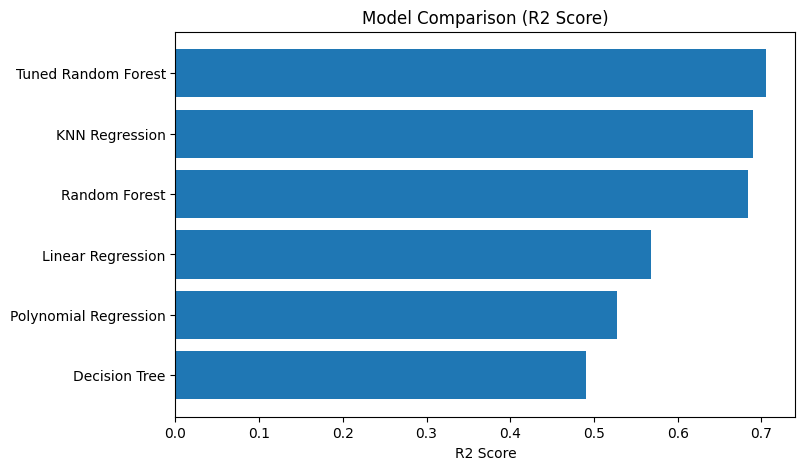

In [96]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.barh(report_df["Model"], report_df["R2 Score"])
plt.gca().invert_yaxis()
plt.title("Model Comparison (R2 Score)")
plt.xlabel("R2 Score")
plt.show()

### 📊 Model Comparison (R² Score)
Tuned Random Forest achieves the highest R² score, followed by KNN and Random Forest, indicating it provides the best predictive performance among all models.

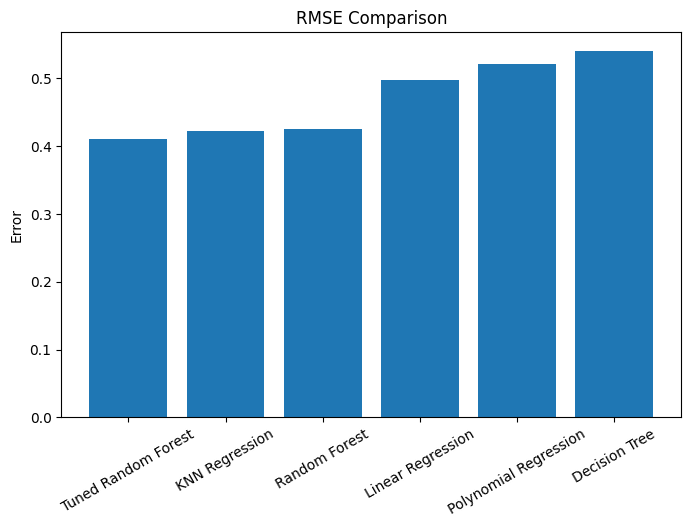

In [97]:
plt.figure(figsize=(8,5))
plt.bar(report_df["Model"], report_df["RMSE"])
plt.xticks(rotation=30)
plt.title("RMSE Comparison")
plt.ylabel("Error")
plt.show()

### 📊 RMSE Comparison
Tuned Random Forest has the lowest RMSE, showing it produces the least prediction error, while Decision Tree has the highest error.

### 📊 Residual Analysis

Residuals = Actual − Predicted

A good model should have:
- Residuals centered around 0
- No strong patterns
- Minimal spread

This helps check model accuracy and bias.

In [98]:
def residual_analysis(y_true, y_pred, model_name):
    residuals = y_true - y_pred

    plt.figure(figsize=(6,4))
    plt.hist(residuals, bins=20)
    plt.title(f"{model_name} Residual Distribution")
    plt.show()

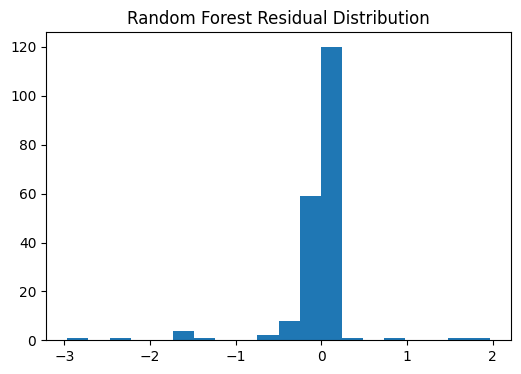

In [99]:
residual_analysis(y_test, y_pred_rf, "Random Forest")

### 📊 Random Forest Residual Distribution
Residuals are tightly concentrated around zero with minimal spread, indicating high accuracy and a well-fitted model.

### 🔹 Final Interpretation

- Models with **lower error (MSE, RMSE, MAE)** perform better
- Models with **higher R²** explain more variance
- **Adjusted R²** ensures model is not over-complex

Final conclusion:
The best model is the one that balances:
✔ High accuracy  
✔ Low error  
✔ Good generalization  